In [50]:
import os
import torch
import numpy as np
import seaborn as sns
import sklearn.metrics as sk
from configs import ModelConfig
import matplotlib.pyplot as plt

### Load Module

In [51]:
def base_directory(model, in_dataset):
    base_directory_name = f"{model}/{in_dataset}/"
    model_statistics_directory = os.path.join(ModelConfig.model_statistics_directory, base_directory_name)
    return model_statistics_directory

def load_weight(model, in_dataset):
    model_statistics_directory = base_directory(model, in_dataset)
    weight_directory = os.path.join(model_statistics_directory, f"Weights/")

    b_fname = weight_directory + "b.npy"
    W_fname = weight_directory + "W.npy"
    b = np.load(b_fname)
    W = np.load(W_fname)

    return b, W

In [52]:
def load_in_stats(model, in_dataset):
    model_statistics_directory = base_directory(model, in_dataset)
    in_features_directory = os.path.join(model_statistics_directory, f"{in_dataset}/in_features/")

    in_avg_fname = in_features_directory + 'avg.npy'
    in_std_fname = in_features_directory + 'std.npy'
    in_max_fname = in_features_directory + 'max.npy'
    in_logit_fname = in_features_directory + 'logit.npy'
    in_labels_fname  = in_features_directory + 'labels.npy'
    in_median_fname  = in_features_directory + 'median.npy'
    in_entropy_fname = in_features_directory + 'entropy.npy'
    
    in_avg = np.load(in_avg_fname)
    in_std = np.load(in_std_fname)
    in_max = np.load(in_max_fname)
    in_logit = np.load(in_logit_fname)
    in_labels = np.load(in_labels_fname)
    in_median = np.load(in_median_fname)
    in_entropy = np.load(in_entropy_fname)

    return in_avg, in_std, in_max, in_logit, in_labels, in_median, in_entropy

In [63]:
def load_out_stats(model, in_dataset, out_dataset):
    model_statistics_directory = base_directory(model, in_dataset)
    out_features_directory = os.path.join(model_statistics_directory, f"{out_dataset}/out_features/")

    out_avg_fname = out_features_directory + 'avg.npy'
    out_std_fname = out_features_directory + 'std.npy'
    out_max_fname = out_features_directory + 'max.npy'
    out_logit_fname = out_features_directory + 'logit.npy'
    out_median_fname  = out_features_directory + 'median.npy'
    out_entropy_fname = out_features_directory + 'entropy.npy'

    out_avg = np.load(out_avg_fname)
    out_std = np.load(out_std_fname)
    out_max = np.load(out_max_fname)
    out_logit = np.load(out_logit_fname)
    out_median = np.load(out_median_fname)
    out_entropy = np.load(out_entropy_fname)

    total = len(out_avg)
    # ordering = np.random.permutation(10) #torch.randperm(total)
    # out_avg = out_avg[ordering]
    # out_std = out_std[ordering]
    # out_max = out_max[ordering]
    # out_logit = out_logit[ordering]
    # out_median = out_median[ordering]
    # out_entropy = out_entropy[ordering]

    n = int(total * 0.10)
    out_avg = out_avg[:n]
    out_std = out_std[:n]
    out_max = out_max[:n]
    out_logit = out_max[:n]
    out_median = out_median[:n]
    out_entropy = out_entropy[:n]

    return out_avg, out_std, out_max, out_logit, out_median, out_entropy

### Evaluation Module

In [54]:
def stable_cumsum(arr, rtol=1e-05, atol=1e-08):
    """Use high precision for cumsum and check that final value matches sum
    Parameters
    ----------
    arr : array-like
        To be cumulatively summed as flat
    rtol : float
        Relative tolerance, see ``np.allclose``
    atol : float
        Absolute tolerance, see ``np.allclose``
    """
    out = np.cumsum(arr, dtype=np.float64)
    expected = np.sum(arr, dtype=np.float64)
    if not np.allclose(out[-1], expected, rtol=rtol, atol=atol):
        raise RuntimeError('cumsum was found to be unstable: '
                           'its last element does not correspond to sum')
    return out

def fpr_and_fdr_at_recall(y_true, y_score, recall_level=0.95, pos_label=None):
    classes = np.unique(y_true)
    if (pos_label is None and
            not (np.array_equal(classes, [0, 1]) or
                     np.array_equal(classes, [-1, 1]) or
                     np.array_equal(classes, [0]) or
                     np.array_equal(classes, [-1]) or
                     np.array_equal(classes, [1]))):
        raise ValueError("Data is not binary and pos_label is not specified")
    elif pos_label is None:
        pos_label = 1.

    # make y_true a boolean vector
    y_true = (y_true == pos_label)

    # sort scores and corresponding truth values
    desc_score_indices = np.argsort(y_score, kind="mergesort")[::-1]
    y_score = y_score[desc_score_indices]
    y_true = y_true[desc_score_indices]

    # y_score typically has many tied values. Here we extract
    # the indices associated with the distinct values. We also
    # concatenate a value for the end of the curve.
    distinct_value_indices = np.where(np.diff(y_score))[0]
    threshold_idxs = np.r_[distinct_value_indices, y_true.size - 1]

    # accumulate the true positives with decreasing threshold
    tps = stable_cumsum(y_true)[threshold_idxs]
    fps = 1 + threshold_idxs - tps      # add one because of zero-based indexing

    thresholds = y_score[threshold_idxs]

    recall = tps / tps[-1]

    last_ind = tps.searchsorted(tps[-1])
    sl = slice(last_ind, None, -1)      # [last_ind::-1]
    recall, fps, tps, thresholds = np.r_[recall[sl], 1], np.r_[fps[sl], 0], np.r_[tps[sl], 0], thresholds[sl]

    cutoff = np.argmin(np.abs(recall - recall_level))

    return fps[cutoff] / (np.sum(np.logical_not(y_true)))   # , fps[cutoff]/(fps[cutoff] + tps[cutoff])

In [55]:
# Create validation set
# ordering = torch.randperm(len(X_train))
# X_train = X_train[ordering]
# Y_train = Y_train[ordering]
# X_train, X_val = X_train[6000:], X_train[:6000]
# Y_train, Y_val = Y_train[6000:], Y_train[:6000]

In [56]:
# def ash_s(x, p):
#     # x := [bt, d]
#     # x = torch.from_numpy(x)
#     batch_size, c = x.shape

#     s1 = x.sum(dim=1) 
#     k = c - int(np.round(c * p / 100.0))
#     v, i = torch.topk(x, k, dim=1)
#     x_pruned = torch.zeros_like(x)
#     x_pruned.scatter_(dim=1, index=i, src=v)

#     s2 = x_pruned.sum(dim=1)
#     scale = s1 / (s2 ) #+ 1e-8)
#     x_sharpened = x_pruned * torch.exp(scale[:, None])

#     return x_sharpened

def ash_s(x, p):
    # x: [batch_size, c]
    batch_size, c = x.shape

    s1 = np.sum(x, axis=1)  # sum over features for each sample
    k = c - int(np.round(c * p / 100.0))  # number of top values to keep

    # For each row, find top-k indices
    idx = np.argpartition(-x, k-1, axis=1)[:, :k]  # get indices of top-k elements
    mask = np.zeros_like(x, dtype=bool)
    batch_indices = np.arange(batch_size)[:, None]
    mask[batch_indices, idx] = True

    x_pruned = np.where(mask, x, 0)

    s2 = np.sum(x_pruned, axis=1)
    scale = s1 / (s2 + 1e-8)  # add epsilon for numerical stability
    x_sharpened = x_pruned * np.exp(scale[:, None])

    return x_sharpened

def get_features(x, threshold=None, ash_p=None):
    # Rectified Activation
    if threshold is not None:
        x = x.clip(max = threshold) 
    # ASH
    if ash_p is not None:
        # x = x.view(-1, dim_in)
        x = ash_s(x, ash_p)
    return x

def get_logit(features, W, b):
   logits = np.dot(features, W.T) + b
   return logits

def get_energy_score(logits):
    logits = torch.tensor(logits)
    scores = torch.logsumexp(logits.data.cpu(), dim=1).numpy()
    # scores = np.power(scores, 0.8)
    return scores

def get_scales(x, threshold=None, scale_lower_threshold=None):
    if threshold is not None:
        x = np.clip(x, 0, threshold)
    if scale_lower_threshold is not None:
        x[x<scale_lower_threshold] = 0.0
    x = np.mean(x, axis=1)
    return x

def get_measures(_pos, _neg, recall_level=0.95):
    pos = np.array(_pos[:]).reshape((-1, 1))
    neg = np.array(_neg[:]).reshape((-1, 1))
    examples = np.squeeze(np.vstack((pos, neg)))
    labels = np.zeros(len(examples), dtype=np.int32)
    labels[:len(pos)] += 1

    auroc = sk.roc_auc_score(labels, examples)
    aupr = sk.average_precision_score(labels, examples)
    fpr = fpr_and_fdr_at_recall(labels, examples, recall_level)

    return fpr, aupr, auroc

In [57]:
def print_result(fpr_list, auroc_list, aupr_list, out_datasets):
    datasets = out_datasets + ['avg']
    fpr_mean, aupr_mean, auroc_mean = np.mean(fpr_list), np.mean(aupr_list), np.mean(auroc_list)
    fpr_list.append(fpr_mean)
    aupr_list.append(aupr_mean)
    auroc_list.append(auroc_mean)

    print("-" * 55)
    print(f"{'Dataset':<15} | {'FPR95 (%)':<9} | {'AUROC (%)':<9} | {'AUPR (%)':<9}")
    print("-" * 55)
    for i in range(len(fpr_list)):
        dataset = datasets[i]
        if dataset == 'avg':
            print("-" * 55)
        fpr, aupr, auroc = round(fpr_list[i] * 100, 2), round(aupr_list[i] * 100, 2), round(auroc_list[i] * 100, 2)
        print(f"{dataset:<15} | {fpr:<9} | {auroc:<9} | {aupr:<9}")
    print("-" * 55) 

def plot_density(in_scores, out_scores, out_datasets):
    n = len(out_datasets)
    fig, axes = plt.subplots(1, n, figsize=(n*6, 5))
    for i in range(n):
        out_dataset = out_datasets[i]
        sns.kdeplot(in_scores[i], label='in', fill=True, ax=axes[i], color='green')
        sns.kdeplot(out_scores[i], label='ood', fill=True, ax=axes[i], color='red')
        axes[i].set_title(f'{out_dataset}')
        axes[i].set_xlabel('scores')
        axes[i].set_ylabel('density')
        axes[i].legend()
        axes[i].grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [58]:
def get_results(W, b, in_features, in_scales, out_features, out_scales, react_threshold = None, ash_p = None):
    # refine features: ReAct/ASH
    in_features  = get_features(x=in_features, threshold=react_threshold, ash_p=ash_p)
    out_features = get_features(x=out_features, threshold=react_threshold, ash_p=ash_p)

    # logits
    in_logits  = get_logit(in_features, W, b)
    out_logits = get_logit(out_features, W, b)

    # scores
    in_scores  = get_energy_score(in_logits)
    out_scores = get_energy_score(out_logits)

    # scaling
    if out_scales is not None or in_scales is not None:
        assert len(in_scores) == len(in_scales)
        in_scores = in_scores * in_scales

        assert len(out_scores) == len(out_scales)
        out_scores = out_scores * out_scales

    fpr, aupr, auroc = get_measures(in_scores, out_scores)
    return fpr, aupr, auroc, in_scores, out_scores

## CIFAR-10

### ResNet-18

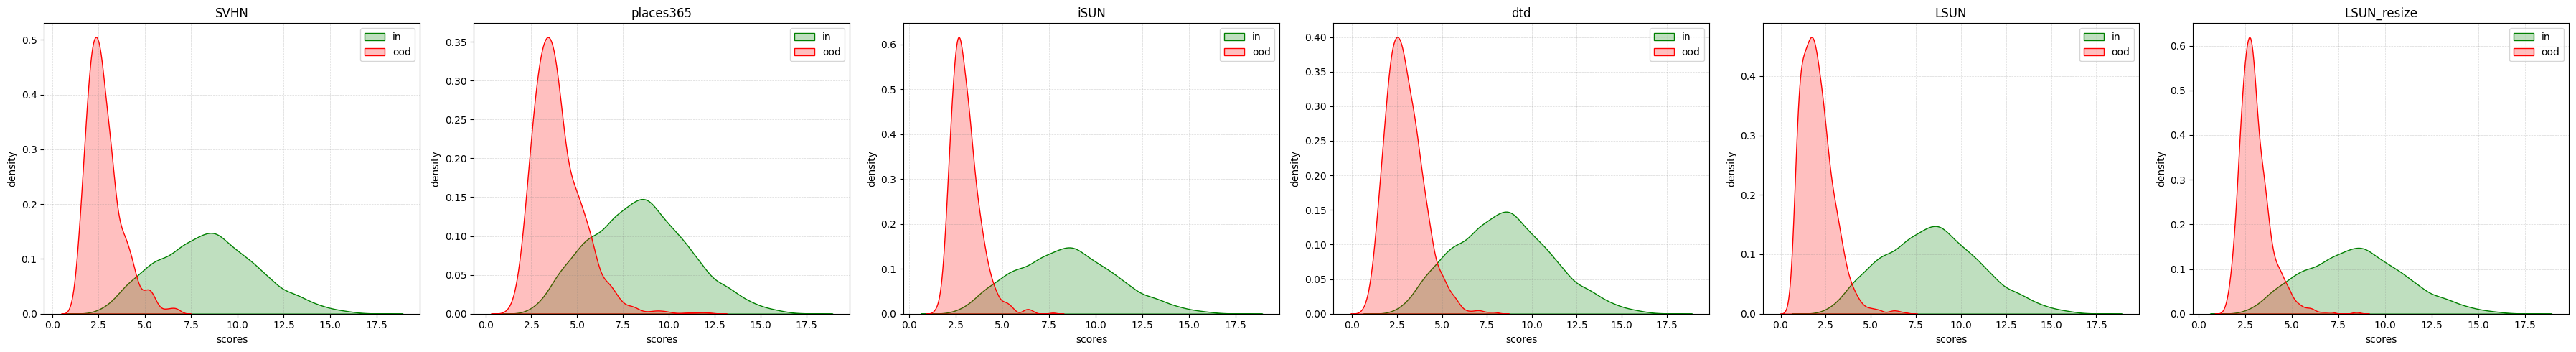

-------------------------------------------------------
Dataset         | FPR95 (%) | AUROC (%) | AUPR (%) 
-------------------------------------------------------
SVHN            | 9.4       | 98.4      | 99.83    
places365       | 35.0      | 93.61     | 99.27    
iSUN            | 7.51      | 98.48     | 99.86    
dtd             | 11.7      | 98.04     | 99.88    
LSUN            | 2.4       | 99.45     | 99.94    
LSUN_resize     | 9.5       | 98.23     | 99.82    
-------------------------------------------------------
avg             | 12.59     | 97.7      | 99.77    
-------------------------------------------------------


In [66]:
in_dataset = 'CIFAR-10'
model = 'resnet18'
out_dataset = 'SVHN'
out_datasets = [ 'SVHN', 'places365', 'iSUN', 'dtd', 'LSUN', 'LSUN_resize']

model_statistics_directory = base_directory(model, in_dataset)
in_scales_directory = os.path.join(model_statistics_directory, f"{in_dataset}/in_scales/")
in_feature_entropy = np.load(in_scales_directory + 'feature_entropy.npy')

b, W = load_weight(model, in_dataset)
fpr_list, aupr_list, auroc_list, in_scores_list, out_scores_list = [], [], [], [], []
in_avg, in_std, in_max, _, in_labels, in_median, in_entropy = load_in_stats(model, in_dataset)

scale_threshold = 3.0
# scale_lower_threshold = 0.1

# in_scales = None
# in_scales = get_scales(in_avg, threshold=scale_threshold)
# in_scales = get_scales(in_std, threshold=scale_threshold)
in_scales = get_scales(in_max, threshold=scale_threshold)
# in_scales = get_scales(in_median, threshold=scale_threshold)
# in_scales = get_scales(in_entropy, threshold=scale_threshold)
# in_scales = 1.0/in_scales


# in_scales = np.sqrt(in_scales)
# in_entropy_scale = np.sum(in_entropy, axis=1)
# in_scales = in_scales / in_entropy_scale


# in_scales = get_scales(in_avg, threshold=0.1) +  get_scales(in_std, threshold=0.15) +  get_scales(in_max, threshold=1.0)
# in_scales = in_scales/get_scales(in_entropy, threshold=4.0)


ash_p = 85
react_threshold = 0.4

for out_dataset in out_datasets:
    out_avg, out_std, out_max, _, out_median, out_entropy = load_out_stats(model, in_dataset, out_dataset)
    out_scales_directory = os.path.join(model_statistics_directory, f"{out_dataset}/out_scales/")
    out_feature_entropy = np.load(out_scales_directory + 'feature_entropy.npy')

    # out_scales = None
    # out_scales = get_scales(out_avg, threshold=scale_threshold)
    # out_scales = get_scales(out_std, threshold=scale_threshold)
    out_scales = get_scales(out_max, threshold=scale_threshold)
    # out_scales = get_scales(out_median, threshold=scale_threshold)
    # out_scales = get_scales(out_entropy, threshold=scale_threshold)
    # out_scales = 1.0/out_scales
    
    
    # out_scales = np.sqrt(out_scales)
    # out_entropy_scale = np.sum(out_entropy, axis=1)
    # out_scales = out_scales /out_entropy_scale
    

    # out_scales = get_scales(out_avg, threshold=0.1)  + get_scales(out_std, threshold=0.15) +  get_scales(out_max, threshold=1.0)
    # out_scales = out_scales/get_scales(out_entropy, threshold=4.0)
    
    
    # fpr, aupr, auroc, in_scores, out_scores = get_results(W, b, in_avg, in_scales, out_avg, out_scales, react_threshold = None, ash_p = None)
    # fpr, aupr, auroc, in_scores, out_scores = get_results(W, b, in_avg, in_scales, out_avg, out_scales, react_threshold = None, ash_p = ash_p)
    fpr, aupr, auroc, in_scores, out_scores = get_results(W, b, in_avg, in_scales, out_avg, out_scales, react_threshold = react_threshold, ash_p = None)
    fpr_list.append(fpr)
    aupr_list.append(aupr)
    auroc_list.append(auroc)
    in_scores_list.append(in_scores)
    out_scores_list.append(out_scores)

plot_density(in_scores_list, out_scores_list, out_datasets)
print_result(fpr_list, auroc_list, aupr_list, out_datasets)

### ResNet-34

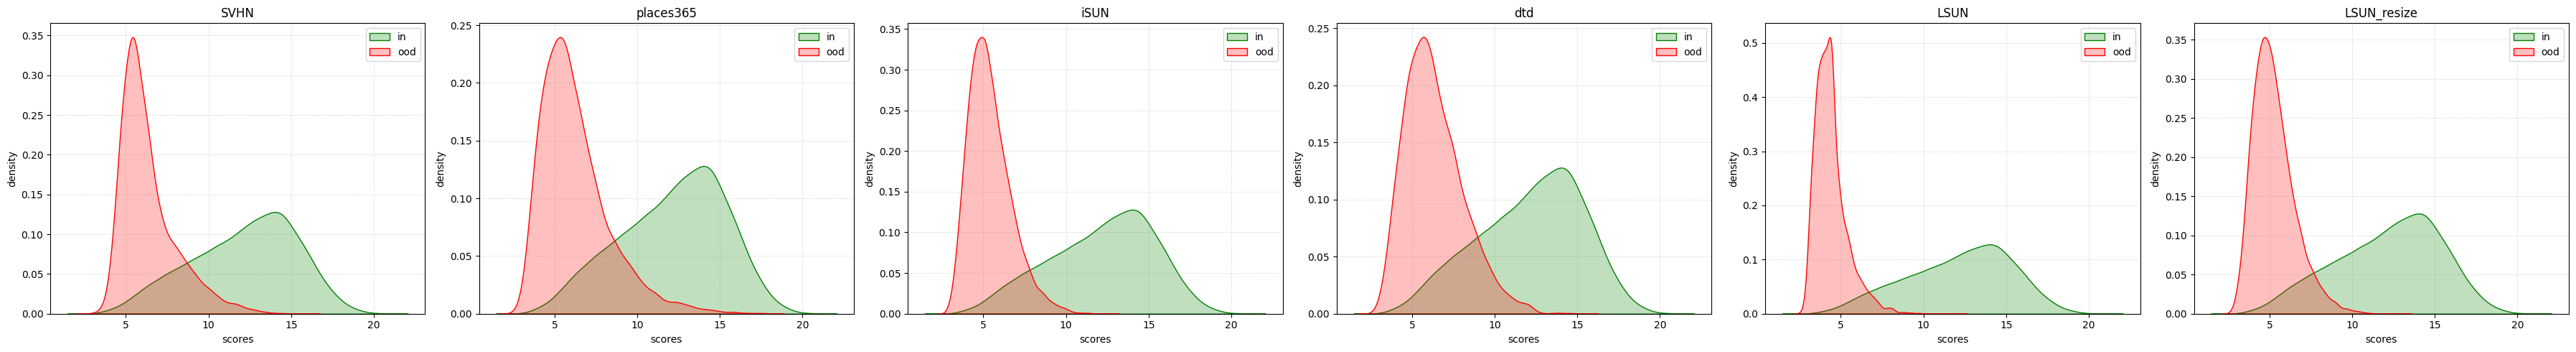

-------------------------------------------------------
Dataset         | FPR95 (%) | AUROC (%) | AUPR (%) 
-------------------------------------------------------
SVHN            | 35.19     | 93.53     | 94.54    
places365       | 36.82     | 92.95     | 93.15    
iSUN            | 18.91     | 97.02     | 97.85    
dtd             | 41.05     | 93.43     | 96.62    
LSUN            | 4.36      | 99.01     | 99.17    
LSUN_resize     | 15.84     | 97.35     | 97.89    
-------------------------------------------------------
avg             | 25.36     | 95.55     | 96.54    
-------------------------------------------------------


In [161]:
in_dataset = 'CIFAR-10'
model = 'resnet34'
out_dataset = 'SVHN'
out_datasets = [ 'SVHN', 'places365', 'iSUN', 'dtd', 'LSUN', 'LSUN_resize']

model_statistics_directory = base_directory(model, in_dataset)
in_scales_directory = os.path.join(model_statistics_directory, f"{in_dataset}/in_scales/")
in_feature_entropy = np.load(in_scales_directory + 'feature_entropy.npy')

b, W = load_weight(model, in_dataset)
fpr_list, aupr_list, auroc_list, in_scores_list, out_scores_list = [], [], [], [], []
in_avg, in_std, in_max, _, in_labels, in_median, in_entropy = load_in_stats(model, in_dataset)

scale_threshold = 1.0
# scale_lower_threshold = 0.1

in_scales = None
# in_scales = get_scales(in_avg, threshold=scale_threshold)
# in_scales = get_scales(in_std, threshold=scale_threshold)
# in_scales = get_scales(in_max, threshold=scale_threshold)
# in_scales = get_scales(in_median, threshold=scale_threshold)
# in_scales = get_scales(in_entropy, threshold=scale_threshold)
# in_scales = 1.0/in_scales


# in_scales = np.sqrt(in_scales)
# in_entropy_scale = np.sum(in_entropy, axis=1)
# in_scales = in_scales / in_entropy_scale


# in_scales = get_scales(in_avg, threshold=0.1) +  get_scales(in_std, threshold=0.15) +  get_scales(in_max, threshold=1.0)
# in_scales = in_scales/get_scales(in_entropy, threshold=4.0)


ash_p = 85
react_threshold = 1.0

for out_dataset in out_datasets:
    out_avg, out_std, out_max, _, out_median, out_entropy = load_out_stats(model, in_dataset, out_dataset)
    out_scales_directory = os.path.join(model_statistics_directory, f"{out_dataset}/out_scales/")
    out_feature_entropy = np.load(out_scales_directory + 'feature_entropy.npy')

    out_scales = None
    # out_scales = get_scales(out_avg, threshold=scale_threshold)
    # out_scales = get_scales(out_std, threshold=scale_threshold)
    # out_scales = get_scales(out_max, threshold=scale_threshold)
    # out_scales = get_scales(out_median, threshold=scale_threshold)
    # out_scales = get_scales(out_entropy, threshold=scale_threshold)
    # out_scales = 1.0/out_scales
    
    
    # out_scales = np.sqrt(out_scales)
    # out_entropy_scale = np.sum(out_entropy, axis=1)
    # out_scales = out_scales /out_entropy_scale
    

    # out_scales = get_scales(out_avg, threshold=0.1)  + get_scales(out_std, threshold=0.15) +  get_scales(out_max, threshold=1.0)
    # out_scales = out_scales/get_scales(out_entropy, threshold=4.0)
    
    
    # fpr, aupr, auroc, in_scores, out_scores = get_results(W, b, in_avg, in_scales, out_avg, out_scales, react_threshold = None, ash_p = None)
    # fpr, aupr, auroc, in_scores, out_scores = get_results(W, b, in_avg, in_scales, out_avg, out_scales, react_threshold = None, ash_p = ash_p)
    fpr, aupr, auroc, in_scores, out_scores = get_results(W, b, in_avg, in_scales, out_avg, out_scales, react_threshold = react_threshold, ash_p = None)
    fpr_list.append(fpr)
    aupr_list.append(aupr)
    auroc_list.append(auroc)
    in_scores_list.append(in_scores)
    out_scores_list.append(out_scores)

plot_density(in_scores_list, out_scores_list, out_datasets)
print_result(fpr_list, auroc_list, aupr_list, out_datasets)

### DenseNet-101

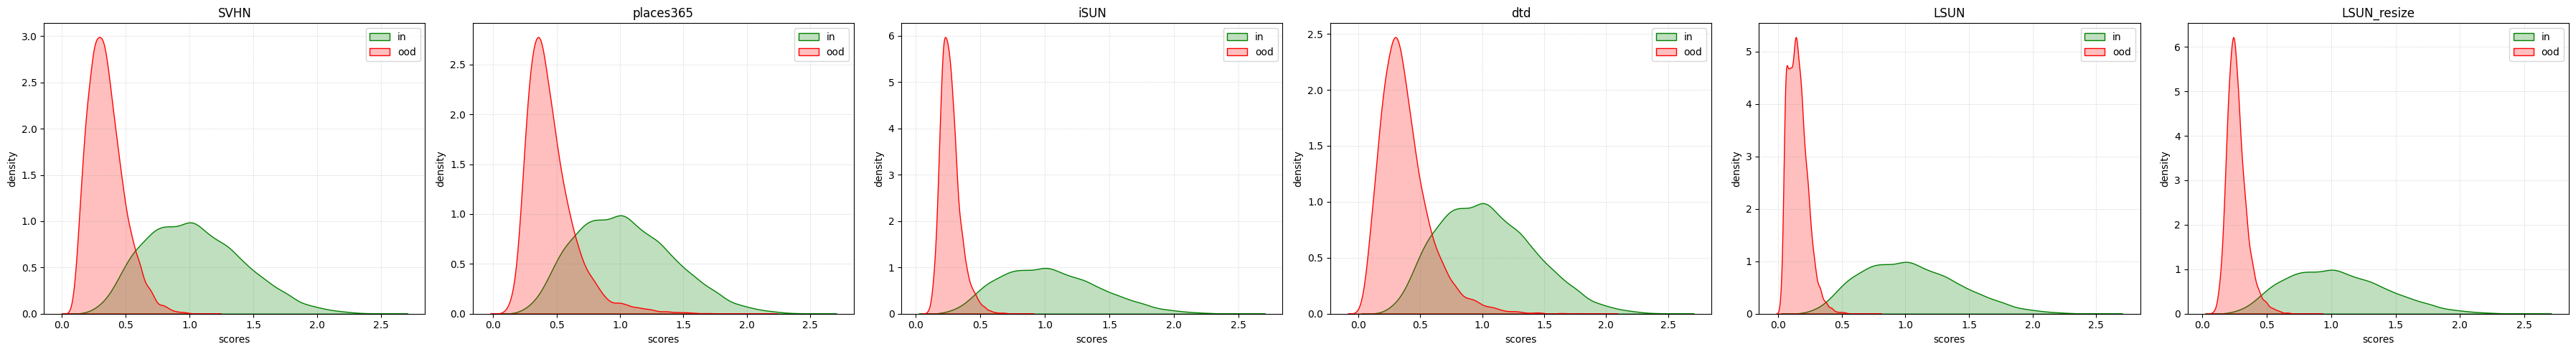

-------------------------------------------------------
Dataset         | FPR95 (%) | AUROC (%) | AUPR (%) 
-------------------------------------------------------
SVHN            | 16.7      | 97.14     | 97.48    
places365       | 35.05     | 92.45     | 92.19    
iSUN            | 1.93      | 99.42     | 99.54    
dtd             | 23.92     | 94.74     | 96.61    
LSUN            | 0.24      | 99.91     | 99.91    
LSUN_resize     | 2.17      | 99.39     | 99.47    
-------------------------------------------------------
avg             | 13.33     | 97.17     | 97.53    
-------------------------------------------------------


In [172]:
in_dataset = 'CIFAR-10'
model = 'densenet101'
out_dataset = 'SVHN'
out_datasets = [ 'SVHN', 'places365', 'iSUN', 'dtd', 'LSUN', 'LSUN_resize']

model_statistics_directory = base_directory(model, in_dataset)
in_scales_directory = os.path.join(model_statistics_directory, f"{in_dataset}/in_scales/")
in_feature_entropy = np.load(in_scales_directory + 'feature_entropy.npy')

b, W = load_weight(model, in_dataset)
fpr_list, aupr_list, auroc_list, in_scores_list, out_scores_list = [], [], [], [], []
in_avg, in_std, in_max, _, in_labels, in_median, in_entropy = load_in_stats(model, in_dataset)

scale_threshold = 0.5
# scale_lower_threshold = 0.1

# in_scales = None
in_scales = get_scales(in_avg, threshold=scale_threshold)
# in_scales = get_scales(in_std, threshold=scale_threshold)
# in_scales = get_scales(in_max, threshold=scale_threshold)
# in_scales = get_scales(in_median, threshold=scale_threshold)
# in_scales = get_scales(in_entropy, threshold=scale_threshold)
# in_scales = 1.0/in_scales


# in_scales = np.sqrt(in_scales)
# in_entropy_scale = np.sum(in_entropy, axis=1)
# in_scales = in_scales / in_entropy_scale


# in_scales = get_scales(in_avg, threshold=0.1) +  get_scales(in_std, threshold=0.15) +  get_scales(in_max, threshold=1.0)
# in_scales = in_scales/get_scales(in_entropy, threshold=4.0)


ash_p = 85
react_threshold = 1.0

for out_dataset in out_datasets:
    out_avg, out_std, out_max, _, out_median, out_entropy = load_out_stats(model, in_dataset, out_dataset)
    out_scales_directory = os.path.join(model_statistics_directory, f"{out_dataset}/out_scales/")
    out_feature_entropy = np.load(out_scales_directory + 'feature_entropy.npy')

    # out_scales = None
    out_scales = get_scales(out_avg, threshold=scale_threshold)
    # out_scales = get_scales(out_std, threshold=scale_threshold)
    # out_scales = get_scales(out_max, threshold=scale_threshold)
    # out_scales = get_scales(out_median, threshold=scale_threshold)
    # out_scales = get_scales(out_entropy, threshold=scale_threshold)
    # out_scales = 1.0/out_scales
    
    
    # out_scales = np.sqrt(out_scales)
    # out_entropy_scale = np.sum(out_entropy, axis=1)
    # out_scales = out_scales /out_entropy_scale
    

    # out_scales = get_scales(out_avg, threshold=0.1)  + get_scales(out_std, threshold=0.15) +  get_scales(out_max, threshold=1.0)
    # out_scales = out_scales/get_scales(out_entropy, threshold=4.0)
    
    
    fpr, aupr, auroc, in_scores, out_scores = get_results(W, b, in_avg, in_scales, out_avg, out_scales, react_threshold = None, ash_p = None)
    # fpr, aupr, auroc, in_scores, out_scores = get_results(W, b, in_avg, in_scales, out_avg, out_scales, react_threshold = None, ash_p = ash_p)
    # fpr, aupr, auroc, in_scores, out_scores = get_results(W, b, in_avg, in_scales, out_avg, out_scales, react_threshold = react_threshold, ash_p = None)
    fpr_list.append(fpr)
    aupr_list.append(aupr)
    auroc_list.append(auroc)
    in_scores_list.append(in_scores)
    out_scores_list.append(out_scores)

plot_density(in_scores_list, out_scores_list, out_datasets)
print_result(fpr_list, auroc_list, aupr_list, out_datasets)

## CIFAR-100

### ResNet-18

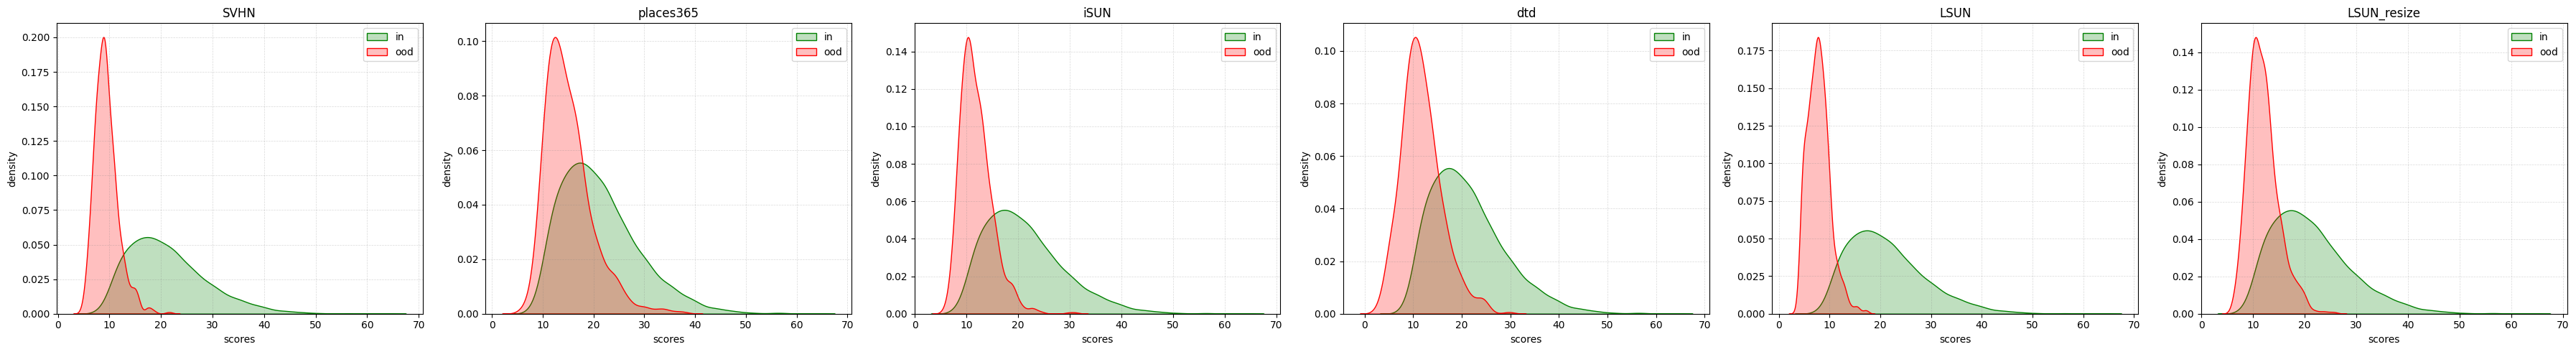

-------------------------------------------------------
Dataset         | FPR95 (%) | AUROC (%) | AUPR (%) 
-------------------------------------------------------
SVHN            | 17.1      | 96.77     | 99.65    
places365       | 81.6      | 75.77     | 96.74    
iSUN            | 51.68     | 89.5      | 98.92    
dtd             | 50.71     | 88.03     | 99.16    
LSUN            | 7.8       | 98.67     | 99.86    
LSUN_resize     | 54.4      | 89.46     | 98.82    
-------------------------------------------------------
avg             | 43.88     | 89.7      | 98.86    
-------------------------------------------------------


In [65]:
in_dataset = 'CIFAR-100'
model = 'resnet18'
out_dataset = 'SVHN'
out_datasets = [ 'SVHN', 'places365', 'iSUN', 'dtd', 'LSUN', 'LSUN_resize']

model_statistics_directory = base_directory(model, in_dataset)
in_scales_directory = os.path.join(model_statistics_directory, f"{in_dataset}/in_scales/")
in_feature_entropy = np.load(in_scales_directory + 'feature_entropy.npy')

b, W = load_weight(model, in_dataset)
fpr_list, aupr_list, auroc_list, in_scores_list, out_scores_list = [], [], [], [], []
in_avg, in_std, in_max, _, in_labels, in_median, in_entropy = load_in_stats(model, in_dataset)

scale_threshold = 5.0
scale_lower_threshold = 0.6

# in_scales = None
# in_scales = get_scales(in_avg, threshold=scale_threshold)
# in_scales = get_scales(in_std, threshold=scale_threshold)
in_scales = get_scales(in_max, threshold=scale_threshold, scale_lower_threshold = scale_lower_threshold)
# in_scales = get_scales(in_median, threshold=scale_threshold)
# in_scales = get_scales(in_entropy, threshold=scale_threshold)
# in_scales = 1.0/in_scales


# in_scales = np.sqrt(in_scales)
# in_entropy_scale = np.sum(in_entropy, axis=1)
# in_scales = in_scales / in_entropy_scale


# in_scales = get_scales(in_avg, threshold=0.1) +  get_scales(in_std, threshold=0.15) +  get_scales(in_max, threshold=1.0)
# in_scales = in_scales/get_scales(in_entropy, threshold=4.0)


ash_p = 85
react_threshold = 0.4

for out_dataset in out_datasets:
    out_avg, out_std, out_max, _, out_median, out_entropy = load_out_stats(model, in_dataset, out_dataset)
    out_scales_directory = os.path.join(model_statistics_directory, f"{out_dataset}/out_scales/")
    out_feature_entropy = np.load(out_scales_directory + 'feature_entropy.npy')

    # out_scales = None
    # out_scales = get_scales(out_avg, threshold=scale_threshold)
    # out_scales = get_scales(out_std, threshold=scale_threshold)
    out_scales = get_scales(out_max, threshold=scale_threshold, scale_lower_threshold = scale_lower_threshold)
    # out_scales = get_scales(out_median, threshold=scale_threshold)
    # out_scales = get_scales(out_entropy, threshold=scale_threshold)
    # out_scales = 1.0/out_scales
    
    
    # out_scales = np.sqrt(out_scales)
    # out_entropy_scale = np.sum(out_entropy, axis=1)
    # out_scales = out_scales /out_entropy_scale
    

    # out_scales = get_scales(out_avg, threshold=0.1)  + get_scales(out_std, threshold=0.15) +  get_scales(out_max, threshold=1.0)
    # out_scales = out_scales/get_scales(out_entropy, threshold=4.0)
    
    
    fpr, aupr, auroc, in_scores, out_scores = get_results(W, b, in_avg, in_scales, out_avg, out_scales, react_threshold = None, ash_p = None)
    # fpr, aupr, auroc, in_scores, out_scores = get_results(W, b, in_avg, in_scales, out_avg, out_scales, react_threshold = None, ash_p = ash_p)
    # fpr, aupr, auroc, in_scores, out_scores = get_results(W, b, in_avg, in_scales, out_avg, out_scales, react_threshold = react_threshold, ash_p = None)
    fpr_list.append(fpr)
    aupr_list.append(aupr)
    auroc_list.append(auroc)
    in_scores_list.append(in_scores)
    out_scores_list.append(out_scores)

plot_density(in_scores_list, out_scores_list, out_datasets)
print_result(fpr_list, auroc_list, aupr_list, out_datasets)

### ResNet-34

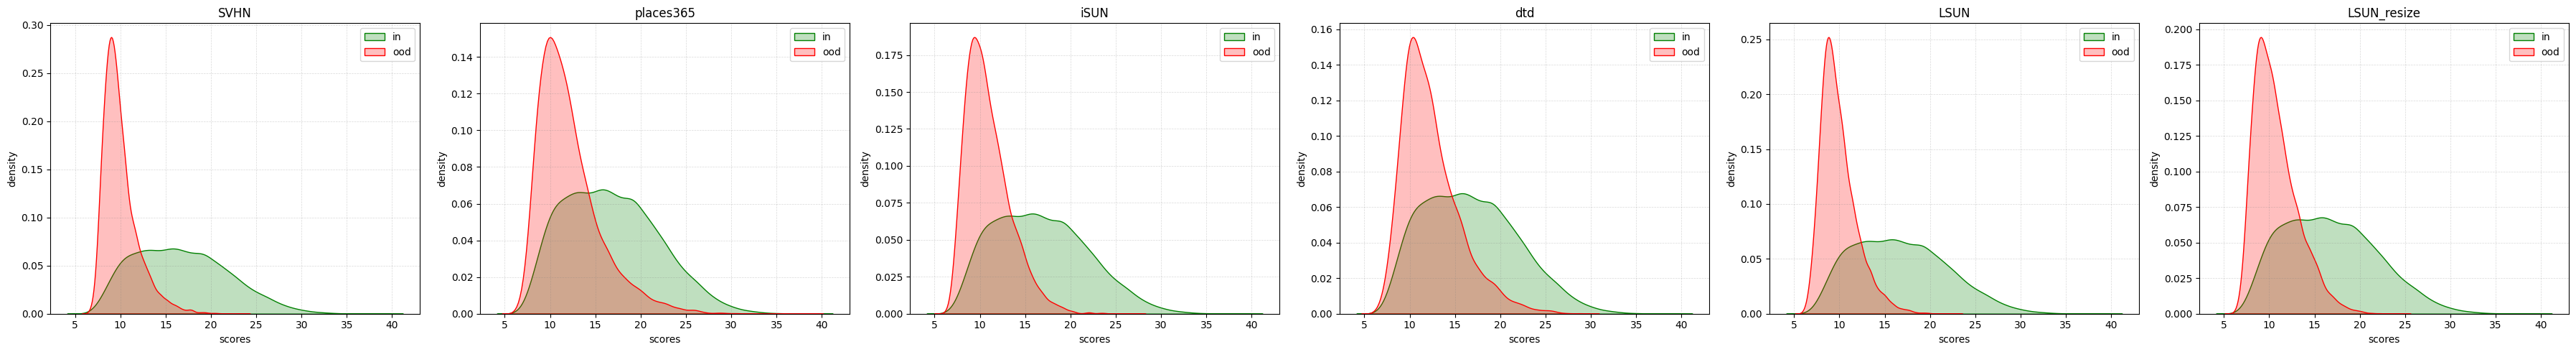

-------------------------------------------------------
Dataset         | FPR95 (%) | AUROC (%) | AUPR (%) 
-------------------------------------------------------
SVHN            | 57.79     | 89.8      | 91.63    
places365       | 81.22     | 77.24     | 77.89    
iSUN            | 71.6      | 84.45     | 88.07    
dtd             | 86.72     | 75.82     | 85.59    
LSUN            | 55.56     | 89.92     | 91.72    
LSUN_resize     | 68.15     | 85.36     | 87.87    
-------------------------------------------------------
avg             | 70.17     | 83.76     | 87.13    
-------------------------------------------------------


In [20]:
in_dataset = 'CIFAR-100'
model = 'resnet34'
out_dataset = 'SVHN'
out_datasets = [ 'SVHN', 'places365', 'iSUN', 'dtd', 'LSUN', 'LSUN_resize']

model_statistics_directory = base_directory(model, in_dataset)
in_scales_directory = os.path.join(model_statistics_directory, f"{in_dataset}/in_scales/")
in_feature_entropy = np.load(in_scales_directory + 'feature_entropy.npy')

b, W = load_weight(model, in_dataset)
fpr_list, aupr_list, auroc_list, in_scores_list, out_scores_list = [], [], [], [], []
in_avg, in_std, in_max, _, in_labels, in_median, in_entropy = load_in_stats(model, in_dataset)

scale_threshold = 5.0
scale_lower_threshold = 0.6

in_scales = None
# in_scales = get_scales(in_avg, threshold=scale_threshold)
# in_scales = get_scales(in_std, threshold=scale_threshold)
# in_scales = get_scales(in_max, threshold=scale_threshold, scale_lower_threshold = scale_lower_threshold)
# in_scales = get_scales(in_median, threshold=scale_threshold)
# in_scales = get_scales(in_entropy, threshold=scale_threshold)
# in_scales = 1.0/in_scales


# in_scales = np.sqrt(in_scales)
# in_entropy_scale = np.sum(in_entropy, axis=1)
# in_scales = in_scales / in_entropy_scale


# in_scales = get_scales(in_avg, threshold=0.1) +  get_scales(in_std, threshold=0.15) +  get_scales(in_max, threshold=1.0)
# in_scales = in_scales/get_scales(in_entropy, threshold=4.0)


ash_p = 85
react_threshold = 0.4

for out_dataset in out_datasets:
    out_avg, out_std, out_max, _, out_median, out_entropy = load_out_stats(model, in_dataset, out_dataset)
    out_scales_directory = os.path.join(model_statistics_directory, f"{out_dataset}/out_scales/")
    out_feature_entropy = np.load(out_scales_directory + 'feature_entropy.npy')

    out_scales = None
    # out_scales = get_scales(out_avg, threshold=scale_threshold)
    # out_scales = get_scales(out_std, threshold=scale_threshold)
    # out_scales = get_scales(out_max, threshold=scale_threshold, scale_lower_threshold = scale_lower_threshold)
    # out_scales = get_scales(out_median, threshold=scale_threshold)
    # out_scales = get_scales(out_entropy, threshold=scale_threshold)
    # out_scales = 1.0/out_scales
    
    
    # out_scales = np.sqrt(out_scales)
    # out_entropy_scale = np.sum(out_entropy, axis=1)
    # out_scales = out_scales /out_entropy_scale
    

    # out_scales = get_scales(out_avg, threshold=0.1)  + get_scales(out_std, threshold=0.15) +  get_scales(out_max, threshold=1.0)
    # out_scales = out_scales/get_scales(out_entropy, threshold=4.0)
    
    
    fpr, aupr, auroc, in_scores, out_scores = get_results(W, b, in_avg, in_scales, out_avg, out_scales, react_threshold = None, ash_p = None)
    # fpr, aupr, auroc, in_scores, out_scores = get_results(W, b, in_avg, in_scales, out_avg, out_scales, react_threshold = None, ash_p = ash_p)
    # fpr, aupr, auroc, in_scores, out_scores = get_results(W, b, in_avg, in_scales, out_avg, out_scales, react_threshold = react_threshold, ash_p = None)
    fpr_list.append(fpr)
    aupr_list.append(aupr)
    auroc_list.append(auroc)
    in_scores_list.append(in_scores)
    out_scores_list.append(out_scores)

plot_density(in_scores_list, out_scores_list, out_datasets)
print_result(fpr_list, auroc_list, aupr_list, out_datasets)

### DenseNet-101

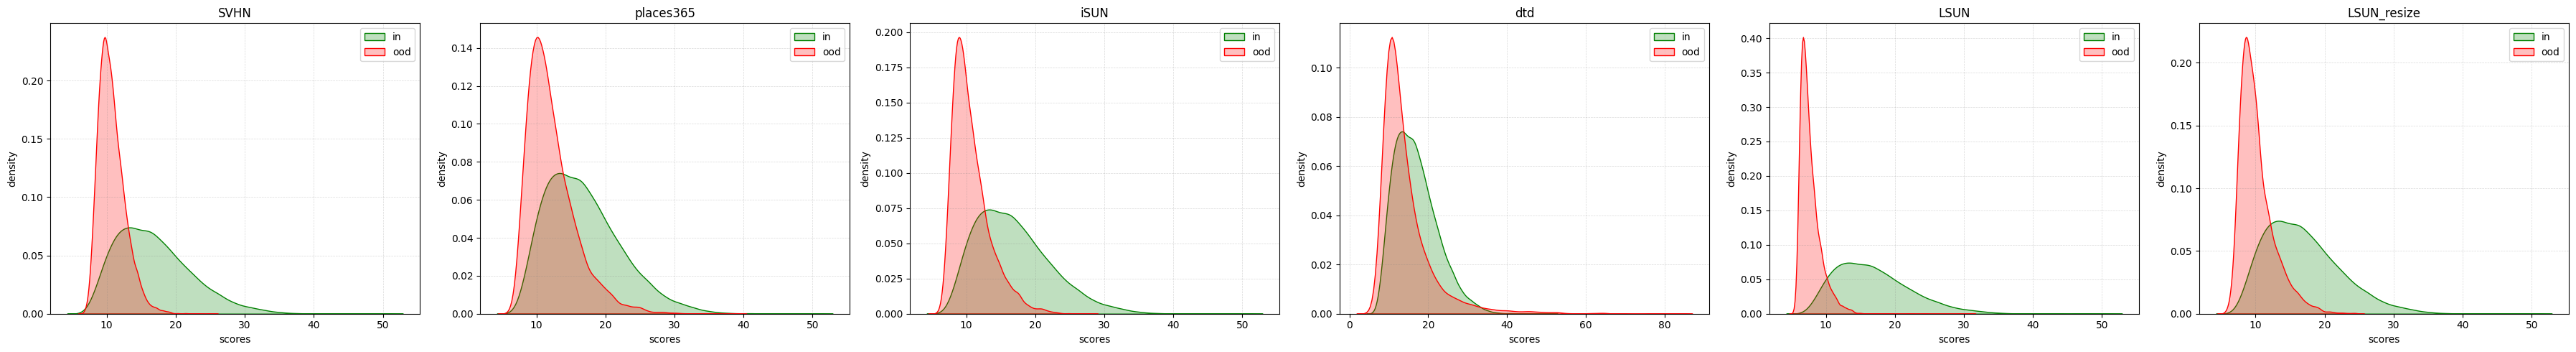

-------------------------------------------------------
Dataset         | FPR95 (%) | AUROC (%) | AUPR (%) 
-------------------------------------------------------
SVHN            | 70.99     | 86.66     | 89.45    
places365       | 77.28     | 76.94     | 77.12    
iSUN            | 59.39     | 85.68     | 87.73    
dtd             | 83.49     | 67.47     | 73.09    
LSUN            | 11.45     | 97.89     | 97.92    
LSUN_resize     | 50.9      | 88.57     | 89.33    
-------------------------------------------------------
avg             | 58.92     | 83.87     | 85.77    
-------------------------------------------------------


In [21]:
in_dataset = 'CIFAR-100'
model = 'densenet101'
out_dataset = 'SVHN'
out_datasets = [ 'SVHN', 'places365', 'iSUN', 'dtd', 'LSUN', 'LSUN_resize']

model_statistics_directory = base_directory(model, in_dataset)
in_scales_directory = os.path.join(model_statistics_directory, f"{in_dataset}/in_scales/")
in_feature_entropy = np.load(in_scales_directory + 'feature_entropy.npy')

b, W = load_weight(model, in_dataset)
fpr_list, aupr_list, auroc_list, in_scores_list, out_scores_list = [], [], [], [], []
in_avg, in_std, in_max, _, in_labels, in_median, in_entropy = load_in_stats(model, in_dataset)

scale_threshold = 5.0
scale_lower_threshold = 0.6

in_scales = None
# in_scales = get_scales(in_avg, threshold=scale_threshold)
# in_scales = get_scales(in_std, threshold=scale_threshold)
# in_scales = get_scales(in_max, threshold=scale_threshold, scale_lower_threshold = scale_lower_threshold)
# in_scales = get_scales(in_median, threshold=scale_threshold)
# in_scales = get_scales(in_entropy, threshold=scale_threshold)
# in_scales = 1.0/in_scales


# in_scales = np.sqrt(in_scales)
# in_entropy_scale = np.sum(in_entropy, axis=1)
# in_scales = in_scales / in_entropy_scale


# in_scales = get_scales(in_avg, threshold=0.1) +  get_scales(in_std, threshold=0.15) +  get_scales(in_max, threshold=1.0)
# in_scales = in_scales/get_scales(in_entropy, threshold=4.0)


ash_p = 85
react_threshold = 0.4

for out_dataset in out_datasets:
    out_avg, out_std, out_max, _, out_median, out_entropy = load_out_stats(model, in_dataset, out_dataset)
    out_scales_directory = os.path.join(model_statistics_directory, f"{out_dataset}/out_scales/")
    out_feature_entropy = np.load(out_scales_directory + 'feature_entropy.npy')

    out_scales = None
    # out_scales = get_scales(out_avg, threshold=scale_threshold)
    # out_scales = get_scales(out_std, threshold=scale_threshold)
    # out_scales = get_scales(out_max, threshold=scale_threshold, scale_lower_threshold = scale_lower_threshold)
    # out_scales = get_scales(out_median, threshold=scale_threshold)
    # out_scales = get_scales(out_entropy, threshold=scale_threshold)
    # out_scales = 1.0/out_scales
    
    
    # out_scales = np.sqrt(out_scales)
    # out_entropy_scale = np.sum(out_entropy, axis=1)
    # out_scales = out_scales /out_entropy_scale
    

    # out_scales = get_scales(out_avg, threshold=0.1)  + get_scales(out_std, threshold=0.15) +  get_scales(out_max, threshold=1.0)
    # out_scales = out_scales/get_scales(out_entropy, threshold=4.0)
    
    
    fpr, aupr, auroc, in_scores, out_scores = get_results(W, b, in_avg, in_scales, out_avg, out_scales, react_threshold = None, ash_p = None)
    # fpr, aupr, auroc, in_scores, out_scores = get_results(W, b, in_avg, in_scales, out_avg, out_scales, react_threshold = None, ash_p = ash_p)
    # fpr, aupr, auroc, in_scores, out_scores = get_results(W, b, in_avg, in_scales, out_avg, out_scales, react_threshold = react_threshold, ash_p = None)
    fpr_list.append(fpr)
    aupr_list.append(aupr)
    auroc_list.append(auroc)
    in_scores_list.append(in_scores)
    out_scores_list.append(out_scores)

plot_density(in_scores_list, out_scores_list, out_datasets)
print_result(fpr_list, auroc_list, aupr_list, out_datasets)

## ImageNet-1k

#### ResNet-50

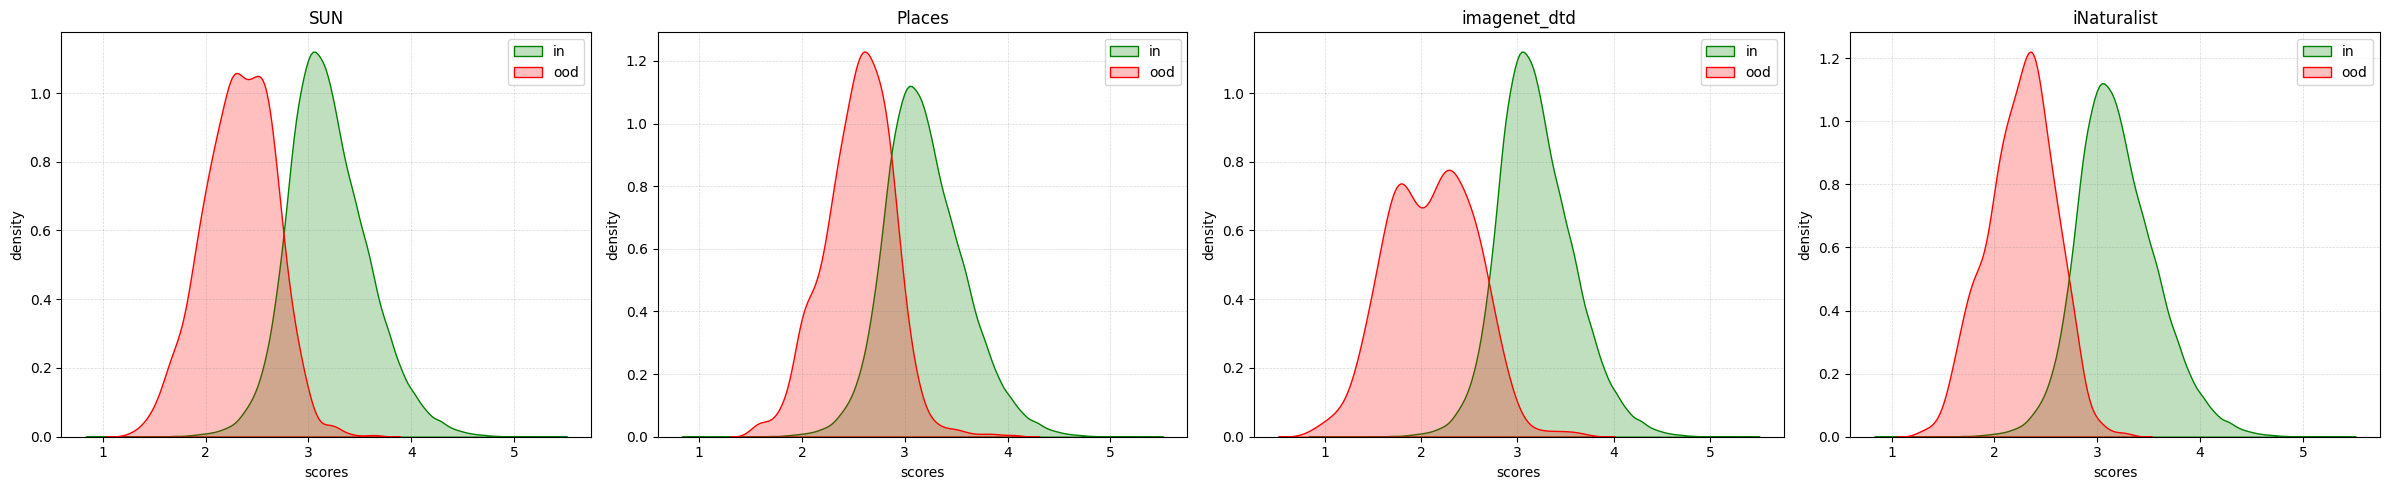

-------------------------------------------------------
Dataset         | FPR95 (%) | AUROC (%) | AUPR (%) 
-------------------------------------------------------
SUN             | 18.9      | 96.2      | 99.91    
Places          | 43.5      | 90.85     | 99.77    
imagenet_dtd    | 12.59     | 97.22     | 99.96    
iNaturalist     | 12.8      | 97.53     | 99.95    
-------------------------------------------------------
avg             | 21.95     | 95.45     | 99.9     
-------------------------------------------------------


In [67]:
in_dataset = 'ImageNet-1K'
model = 'resnet_imagenet50'
out_dataset = 'SUN'
out_datasets = ['SUN', 'Places', 'imagenet_dtd', 'iNaturalist']

model_statistics_directory = base_directory(model, in_dataset)
in_scales_directory = os.path.join(model_statistics_directory, f"{in_dataset}/in_scales/")
in_feature_entropy = np.load(in_scales_directory + 'feature_entropy.npy')

b, W = load_weight(model, in_dataset)
fpr_list, aupr_list, auroc_list, in_scores_list, out_scores_list = [], [], [], [], []
in_avg, in_std, in_max, _, in_labels, in_median, in_entropy = load_in_stats(model, in_dataset)

scale_threshold = 0.1
# scale_lower_threshold = 0.01
# in_scales = in_feature_entropy
# in_scales = get_scales(in_entropy, threshold=scale_threshold)
# in_scales = 1.0/in_scales
# in_scales = get_scales(in_median, threshold=scale_threshold)
# in_scales = get_scales(in_max, threshold=scale_threshold)
# in_scales = get_scales(in_std, threshold=scale_threshold)
# in_scales = get_scales(in_avg, threshold=scale_threshold)
# in_scales = np.sqrt(in_scales)
# in_entropy_scale = np.sum(in_entropy, axis=1)
# in_scales = in_scales / in_entropy_scale
# in_scales = None

in_scales = get_scales(in_avg, threshold=0.1) +  get_scales(in_std, threshold=0.15) +  get_scales(in_max, threshold=1.0)
in_scales = in_scales/get_scales(in_entropy, threshold=4.0)

ash_p = 90
react_threshold = 1.0

for out_dataset in out_datasets:
    out_avg, out_std, out_max, _, out_median, out_entropy = load_out_stats(model, in_dataset, out_dataset)
    out_scales_directory = os.path.join(model_statistics_directory, f"{out_dataset}/out_scales/")
    out_feature_entropy = np.load(out_scales_directory + 'feature_entropy.npy')

    # out_scales = out_feature_entropy
    # out_scales = get_scales(out_entropy, threshold=scale_threshold)
    # out_scales = 1.0/out_scales
    # out_scales = get_scales(out_median, threshold=scale_threshold)
    # out_scales = get_scales(out_max, threshold=scale_threshold)
    # out_scales = get_scales(out_std, threshold=scale_threshold)
    # out_scales = get_scales(out_avg, threshold=scale_threshold)
    # out_scales = np.sqrt(out_scales)
    # out_entropy_scale = np.sum(out_entropy, axis=1)
    # out_scales = out_scales /out_entropy_scale
    # out_scales = None

    out_scales = get_scales(out_avg, threshold=0.1)  + get_scales(out_std, threshold=0.15) +  get_scales(out_max, threshold=1.0)
    out_scales = out_scales/get_scales(out_entropy, threshold=4.0)
    
    
    # fpr, aupr, auroc, in_scores, out_scores = get_results(W, b, in_avg, in_scales, out_avg, out_scales, react_threshold = None, ash_p = ash_p)
    fpr, aupr, auroc, in_scores, out_scores = get_results(W, b, in_avg, in_scales, out_avg, out_scales, react_threshold = react_threshold, ash_p = None)
    fpr_list.append(fpr)
    aupr_list.append(aupr)
    auroc_list.append(auroc)
    in_scores_list.append(in_scores)
    out_scores_list.append(out_scores)

plot_density(in_scores_list, out_scores_list, out_datasets)
print_result(fpr_list, auroc_list, aupr_list, out_datasets)

#### ResNet-34

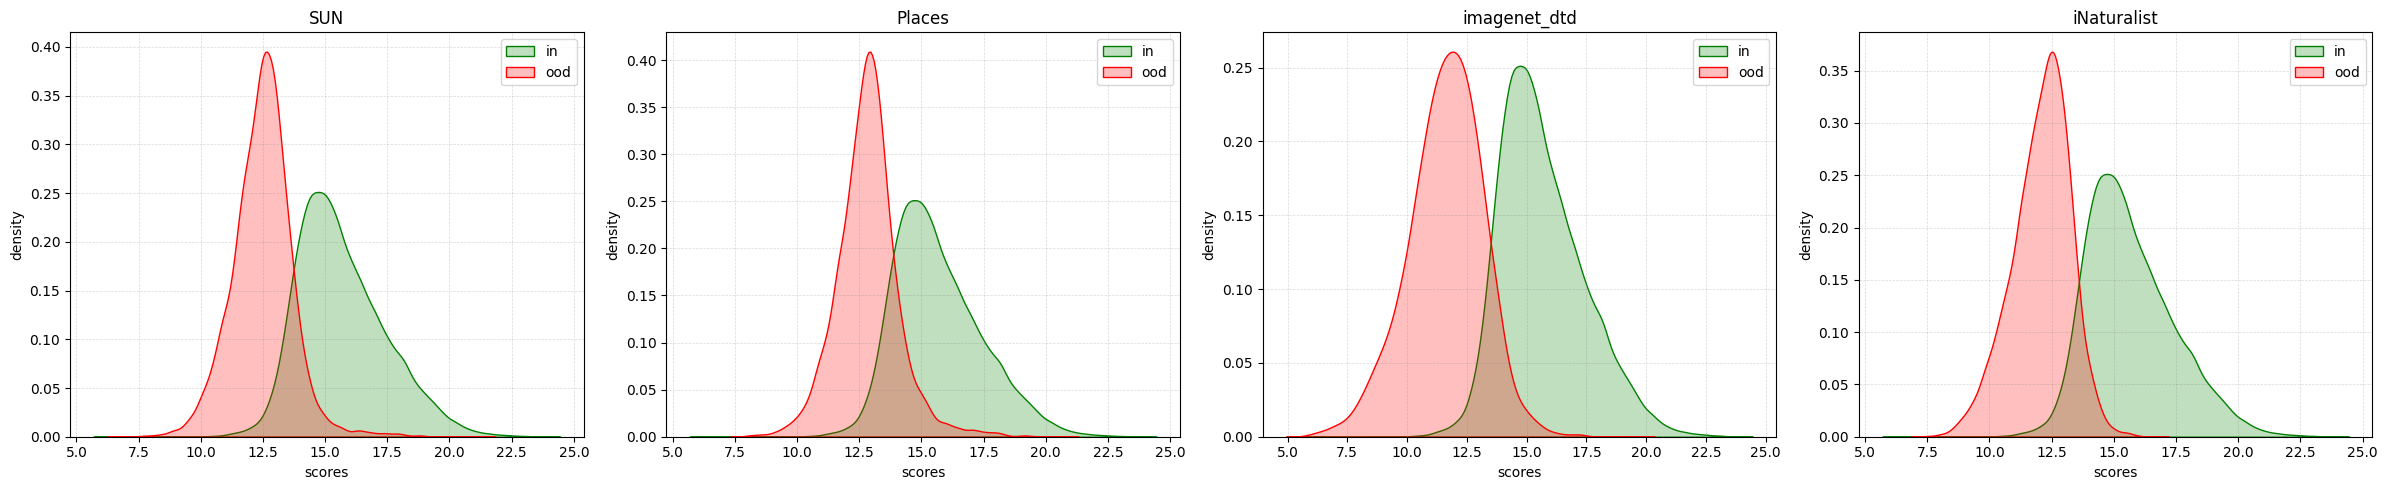

-------------------------------------------------------
Dataset         | FPR95 (%) | AUROC (%) | AUPR (%) 
-------------------------------------------------------
SUN             | 21.54     | 95.0      | 98.74    
Places          | 32.21     | 92.31     | 98.02    
imagenet_dtd    | 13.05     | 97.03     | 99.6     
iNaturalist     | 13.51     | 97.3      | 99.44    
-------------------------------------------------------
avg             | 20.08     | 95.41     | 98.95    
-------------------------------------------------------


In [29]:
in_dataset = 'ImageNet-1K'
model = 'resnet_imagenet34'
out_dataset = 'SUN'
out_datasets = ['SUN', 'Places', 'imagenet_dtd', 'iNaturalist']

model_statistics_directory = base_directory(model, in_dataset)
in_scales_directory = os.path.join(model_statistics_directory, f"{in_dataset}/in_scales/")
in_feature_entropy = np.load(in_scales_directory + 'feature_entropy.npy')

b, W = load_weight(model, in_dataset)
fpr_list, aupr_list, auroc_list, in_scores_list, out_scores_list = [], [], [], [], []
in_avg, in_std, in_max, _, in_labels, in_median, in_entropy = load_in_stats(model, in_dataset)

scale_threshold = 0.1
# in_scales = in_feature_entropy
# in_scales = get_scales(in_entropy, threshold=scale_threshold)
# in_scales = 1.0/in_scales
# in_scales = get_scales(in_median, threshold=scale_threshold)
# in_scales = get_scales(in_max, threshold=scale_threshold)
# in_scales = get_scales(in_std, threshold=scale_threshold)
# in_scales = get_scales(in_avg, threshold=scale_threshold)
# in_scales = np.sqrt(in_scales)
# in_entropy_scale = np.sum(in_entropy, axis=1)
# in_scales = in_scales / in_entropy_scale
# in_scales = None

in_scales = get_scales(in_avg, threshold=0.1) +  get_scales(in_std, threshold=0.35) +  get_scales(in_max, threshold=1.2)
# in_scales = in_scales/get_scales(in_entropy, threshold=4.0)

ash_p = 90
react_threshold = 2.0

for out_dataset in out_datasets:
    out_avg, out_std, out_max, _, out_median, out_entropy = load_out_stats(model, in_dataset, out_dataset)
    out_scales_directory = os.path.join(model_statistics_directory, f"{out_dataset}/out_scales/")
    out_feature_entropy = np.load(out_scales_directory + 'feature_entropy.npy')

    # out_scales = out_feature_entropy
    # out_scales = get_scales(out_entropy, threshold=scale_threshold)
    # out_scales = 1.0/out_scales
    # out_scales = get_scales(out_median, threshold=scale_threshold)
    # out_scales = get_scales(out_max, threshold=scale_threshold)
    # out_scales = get_scales(out_std, threshold=scale_threshold)
    # out_scales = get_scales(out_avg, threshold=scale_threshold)
    # out_scales = np.sqrt(out_scales)
    # out_entropy_scale = np.sum(out_entropy, axis=1)
    # out_scales = out_scales /out_entropy_scale
    # out_scales = None

    out_scales = get_scales(out_avg, threshold=0.1)  + get_scales(out_std, threshold=0.35) +  get_scales(out_max, threshold=1.2)
    # out_scales = out_scales/get_scales(out_entropy, threshold=4.0)
    
    fpr, aupr, auroc, in_scores, out_scores = get_results(W, b, in_avg, in_scales, out_avg, out_scales, react_threshold = react_threshold, ash_p = None)
    fpr_list.append(fpr)
    aupr_list.append(aupr)
    auroc_list.append(auroc)
    in_scores_list.append(in_scores)
    out_scores_list.append(out_scores)

plot_density(in_scores_list, out_scores_list, out_datasets)
print_result(fpr_list, auroc_list, aupr_list, out_datasets)

#### MobileNet-V2

In [ ]:
# def nap_scale(avg_feature, max_feature):
#     epsilon = 1e-10
#     max_by_avg = max_feature / (avg_feature + epsilon)
#     max_by_avg_sq = max_by_avg * max_by_avg
#     scale = np.mean(max_by_avg, axis = 1)
#     scale = np.power(scale, 0.2)
#     return scale

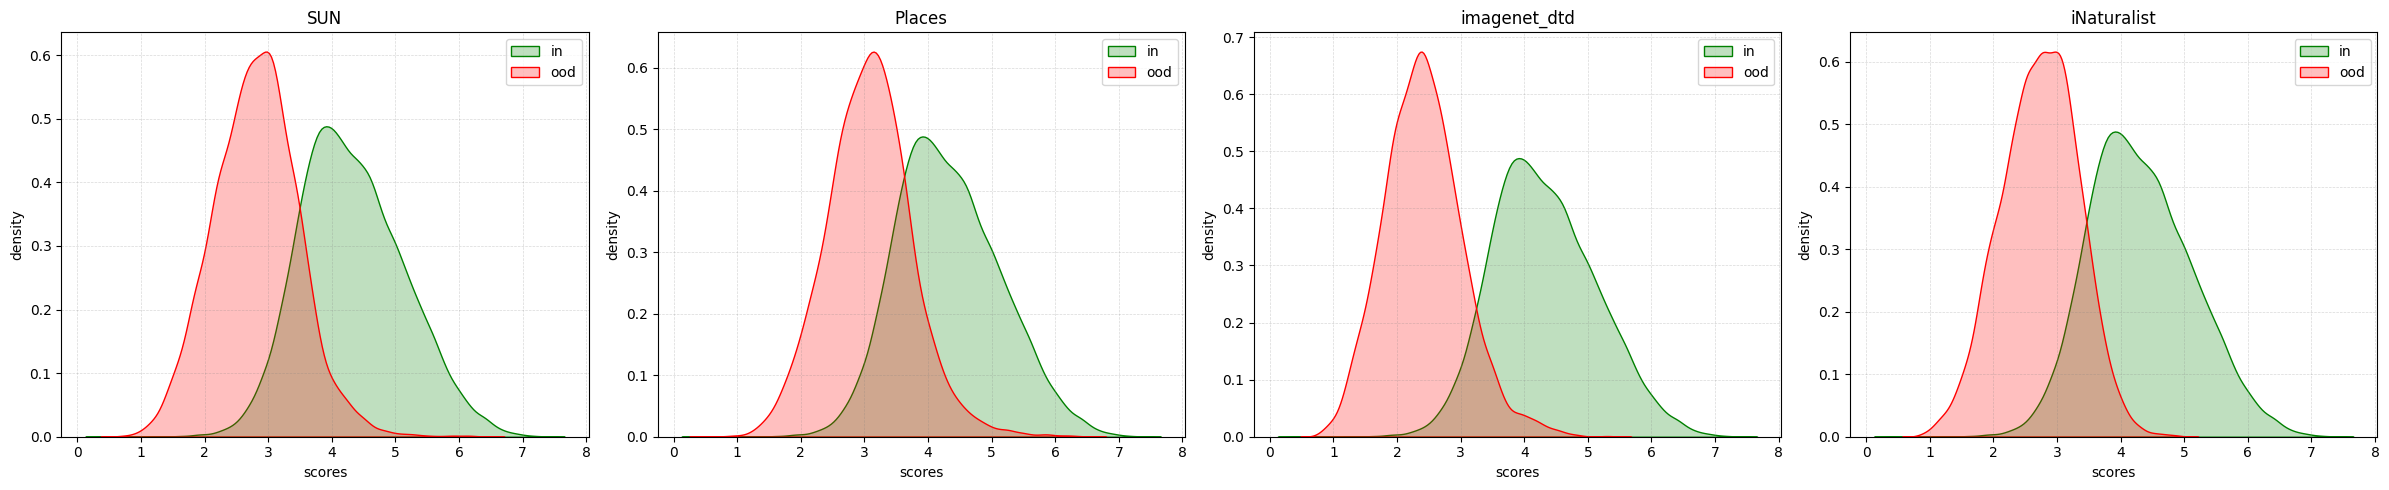

-------------------------------------------------------
Dataset         | FPR95 (%) | AUROC (%) | AUPR (%) 
-------------------------------------------------------
SUN             | 32.77     | 93.04     | 98.33    
Places          | 48.41     | 88.63     | 97.16    
imagenet_dtd    | 12.71     | 97.11     | 99.62    
iNaturalist     | 28.36     | 94.89     | 98.91    
-------------------------------------------------------
avg             | 30.56     | 93.42     | 98.5     
-------------------------------------------------------


In [36]:
in_dataset = 'ImageNet-1K'
model = 'mobilenetv2_imagenet'
out_dataset = 'SUN'
out_datasets = ['SUN', 'Places', 'imagenet_dtd', 'iNaturalist']

model_statistics_directory = base_directory(model, in_dataset)
in_scales_directory = os.path.join(model_statistics_directory, f"{in_dataset}/in_scales/")
in_feature_entropy = np.load(in_scales_directory + 'feature_entropy.npy')

b, W = load_weight(model, in_dataset)
fpr_list, aupr_list, auroc_list, in_scores_list, out_scores_list = [], [], [], [], []
in_avg, in_std, in_max, _, in_labels, in_median, in_entropy = load_in_stats(model, in_dataset)

scale_threshold = 0.7
scale_lower_threshold = None
# in_scales = in_feature_entropy
# in_scales = get_scales(in_entropy, threshold=scale_threshold)
# in_scales = 1.0/in_scales
# in_scales = get_scales(in_median, threshold=scale_threshold)
# in_scales = get_scales(in_max, threshold=scale_threshold, scale_lower_threshold=scale_lower_threshold)
# in_scales = get_scales(in_std, threshold=scale_threshold, scale_lower_threshold=scale_lower_threshold)
in_scales = get_scales(in_avg, threshold=scale_threshold, scale_lower_threshold=scale_lower_threshold)
# in_scales = np.sqrt(in_scales)
# in_entropy_scale = np.sum(in_entropy, axis=1)
# in_scales = in_scales / in_entropy_scale
# in_scales = None

# in_scales = get_scales(in_avg, threshold=0.7) +  get_scales(in_std, threshold=0.4) +  get_scales(in_max, threshold=1.5)
# in_scales = in_scales/get_scales(in_entropy, threshold=4.0)

# in_scales = nap_scale(in_avg, in_max)

ash_p = 90
react_threshold = 1.0

for out_dataset in out_datasets:
    out_avg, out_std, out_max, _, out_median, out_entropy = load_out_stats(model, in_dataset, out_dataset)
    out_scales_directory = os.path.join(model_statistics_directory, f"{out_dataset}/out_scales/")
    out_feature_entropy = np.load(out_scales_directory + 'feature_entropy.npy')

    # out_scales = out_feature_entropy
    # out_scales = get_scales(out_entropy, threshold=scale_threshold)
    # out_scales = 1.0/out_scales
    # out_scales = get_scales(out_median, threshold=scale_threshold)
    # out_scales = get_scales(out_max, threshold=scale_threshold, scale_lower_threshold=scale_lower_threshold)
    # out_scales = get_scales(out_std, threshold=scale_threshold, scale_lower_threshold=scale_lower_threshold)
    out_scales = get_scales(out_avg, threshold=scale_threshold, scale_lower_threshold=scale_lower_threshold)
    # out_scales = np.sqrt(out_scales)
    # out_entropy_scale = np.sum(out_entropy, axis=1)
    # out_scales = out_scales /out_entropy_scale
    # out_scales = None

    # out_scales = get_scales(out_avg, threshold=0.7)  + get_scales(out_std, threshold=0.4) +  get_scales(out_max, threshold=1.5)
    # out_scales = out_scales/get_scales(out_entropy, threshold=4.0)

    # out_scales = nap_scale(out_avg, out_max)
    
    fpr, aupr, auroc, in_scores, out_scores = get_results(W, b, in_avg, in_scales, out_avg, out_scales, react_threshold = react_threshold, ash_p = None)
    fpr_list.append(fpr)
    aupr_list.append(aupr)
    auroc_list.append(auroc)
    in_scores_list.append(in_scores)
    out_scores_list.append(out_scores)

plot_density(in_scores_list, out_scores_list, out_datasets)
print_result(fpr_list, auroc_list, aupr_list, out_datasets)